# Quantum Drude Oscillator

Intermolecular dispersion forces can be determined by calculating the interaction between two molecules; however, the total force does not simply triple when a third molecule is introduced. This phenomenon is referred to as Many-Body Dispersion (MBD). While it is desirable to evaluate dispersion forces using first-principles calculation methods, attempting to do so with multiple specific molecules results in an exorbitant increase in computational complexity.

The Quantum Drude Oscillator (QDO) model [[1](#Jones2013)] is a coarse-grained model that describes "molecules interacting via dispersion forces" as "electrostatic interactions between QDOs." In this model, a QDO is defined as a harmonic oscillator consisting of a pair of fictitious positively and negatively charged particles connected by a spring. QDOs behave as bosons, and in this tutorial, we see how we can treat such bosonic system using classiq [[2](#Anderson2022)].

In [ ]:
!pip install -qq "classiq[chemistry]"

In [1]:
import time
from functools import reduce
from operator import mul

import matplotlib.pyplot as plt
import numpy as np

from classiq import *

## One-dimensional QDO Hamiltonian

In this tutorial, we consider a non-dimensional Hamiltonian for $N$ one-dimensional QDOs which are interacting via quadratic coupling.

$$
\def\H{\hat{H}}
\def\x{\hat{x}}
\def\p{\hat{p}}
\def\bin{\operatorname{bin}}
\def\a{\hat{a}}
\def\aD{\hat{a}^\dagger}

\begin{equation*}
\H = \sum_{i=1}^N (\x_i^2 + \p_i^2) + \sum_{j>i} \gamma_{i,j} \x_i\x_j,
\end{equation*}
$$

where $\x_i$ and $\p_i$ are the bosonic position and momentum operators for oscillator $i$ and $\gamma_{i,j}\in \mathbb{R}$ is the coupling between oscillators  $i$ and $j$.

For simplicity, we assume that all one-dimensional QDOs are identical and aligned parallel to each other and along the inter-oscillator axis, equally separated by distance $R$. In this case, the coupling constant is given by $\gamma_{i,j}=-4\alpha (R|i-j|)^{-3}$, where $\alpha$ is the dipole polarisability.


We need to represent this Hamiltonian in terms of Pauli matrices to be able to implement on quantum circuit.

Unlike fermions, bosonic Fock states cannot be represented by only zeros and ones. Therefore, when  bosons occupy a certain quantum state, we need to encode this by representing the number $n$ as a binary string in the qubit state. In this tutorial, we denote a Fock state expressed in decimal as $|\underline{n}\rangle$ (with an underline), and a Fock state in binary representation as $|\bin(n)\rangle$ (without an underline). Here, $\bin(n)$ represents the binary representation of $n$, and $\bin(n)_i$ denotes the $i$-th bit from the right of the bitstring.

When adopting this binary encoding, there is an upper limit to the number of bosons that can occupy the same quantum state. If we allocate $m$ qubits to the Fock state of each boson, the possible values range from 0 to $2^m - 1$. We define the number of levels we can handle as $d = 2^m$. $d$ must be large enough to make the result as reliable as possible. Although not used in this tutorial, Classiq's `QNum` could potentially handle such bosonic Fock states more intuitively.

The bosonic position and momentum operators can be written using ladder operators as:
$$
\begin{align*}
\x &= \frac{1}{\sqrt{2}}(\aD + \a), \\
\p &= -\frac{i}{\sqrt{2}}(\aD - \a),
\end{align*}
$$
where the ladder operators are expressed using projection operators as follows:
$$
\begin{align*}
\hat{a}^\dagger &= \sum_{n=0}^{d-1} \sqrt{n+1} |\underline{n+1}\rangle\langle\underline{n}|, \\
\hat{a} &= \sum_{n=0}^{d-1} \sqrt{n+1} |\underline{n}\rangle\langle\underline{n+1}|,
\end{align*}
$$
What does this projection operator look like in binary representation? Let's take $|\underline{4}\rangle\langle\underline{3}|$ with a bit length of $m=4$ as an example. In this case, the projection operator is:
$$
\begin{align*}
|\underline{4}\rangle\langle\underline{3}| &= |0100\rangle\langle 0011| \\
&= |0\rangle\langle 0| \otimes |1\rangle\langle 0| \otimes |0\rangle\langle 1|^{\otimes 2}
\end{align*}
$$
As we can see, the operator $|\underline{n+1}\rangle\langle\underline{n}|$ can be divided into three parts:

1. For the bits where ones continue from the $2^0$ position, apply $|0\rangle\langle 1|$.
2. For the rightmost zero, apply $|1\rangle\langle 0|$.
3. For all other bits, there is no change, so apply $|0\rangle\langle 0|$ or $|1\rangle\langle 1|$.

Therefore, $|\underline{n+1}\rangle\langle\underline{n}|$ can be expressed using Pauli matrices as:
$$
\begin{align*}
|\underline{n+1}\rangle\langle\underline{n}| &= \left(\bigotimes_{i=k+1}^{m-1} |\text{bin}(n)_i\rangle\langle\text{bin}(n)_i| \right) \otimes |1\rangle\langle0| \otimes \left(|0\rangle\langle1|\right)^{\otimes k} \\
&= \left(\bigotimes_{i=k+1}^{m-1} \frac{I + (-1)^{\text{bin}(n)_i}Z}{2}\right) \otimes \frac{X-iY}{2} \otimes \left(\frac{X+iY}{2}\right)^{\otimes k},
\end{align*}
$$
where $k$ is the position of the rightmost 0 in $\bin(n)$.

By noting the relationship $|\underline{n+1}\rangle\langle\underline{n}| = (|\underline{n}\rangle\langle\underline{n+1}|)^\dagger$, we can write the QDO Hamiltonian in terms of Pauli matrices. The following code generates the coupling terms for this Hamiltonian.

In [2]:
def get_ith_bit(n, i):
    """Get the i-th bit of an integer.

    Args:
        n (int): Input integer.
        i (int): Bit position to retrieve.

    Returns:
        int: The i-th bit (0 or 1).
    """
    return (n >> i) & 1

In [3]:
def get_rightmost_zero_pos(n):
    """Get the position of the rightmost '0' in an integer.

    Args:
        n (int): Input integer.

    Returns:
        int: Position of the rightmost '0'.
    """
    return (~n & (-~n)).bit_length() - 1

In [4]:
def create_ladder_projector(n: int, qubits: list[int], direction: str) -> SparsePauliOp:
    """Create ladder projector operator for given occupation number.
    'up':   |n+1><n|
    'down': |n><n+1|

    Args:
        n (int): Occupation number.
        qubits (list[int]): List of qubit indices.
        direction (str): 'up' or 'down' for ladder direction.

    Returns:
        SparsePauliOp: Ladder projector operator.
    """
    m = len(qubits)
    if not 0 <= n < 2**m:
        raise ValueError("Occupation number n must be in the range [0, 2^m).")
    paulis_coeffs = []
    k = get_rightmost_zero_pos(n)

    if direction == "up":
        for i in range(k):
            paulis_coeffs.append((Pauli.X(qubits[i]) + 1j * Pauli.Y(qubits[i])) / 2)
        paulis_coeffs.append((Pauli.X(qubits[k]) - 1j * Pauli.Y(qubits[k])) / 2)
    elif direction == "down":  # adjoint of "up"
        for i in range(k):
            paulis_coeffs.append((Pauli.X(qubits[i]) - 1j * Pauli.Y(qubits[i])) / 2)
        paulis_coeffs.append((Pauli.X(qubits[k]) + 1j * Pauli.Y(qubits[k])) / 2)

    for i in range(k + 1, m):
        paulis_coeffs.append(
            (Pauli.I(qubits[i]) + ((-1) ** get_ith_bit(n, i)) * Pauli.Z(qubits[i])) / 2
        )

    return reduce(mul, paulis_coeffs)

In [5]:
# Test the `create_ladder_projector` function
# example: |3><2| = |11><10| for 2 qubits
expected = (Pauli.I(1) - Pauli.Z(1)) / 2 * (Pauli.X(0) - 1j * Pauli.Y(0)) / 2
actual = create_ladder_projector(2, [0, 1], "up")
print("Is the created ladder projector correct?", expected == actual)
print(
    "Are |3><2| and |2><3| Hermitian conjugates?",
    (
        hamiltonian_to_matrix(create_ladder_projector(2, [0, 1], "up")).conj().T
        == hamiltonian_to_matrix(create_ladder_projector(2, [0, 1], "down"))
    ).all(),
)

Is the created ladder projector correct? True
Are |3><2| and |2><3| Hermitian conjugates? True


In [6]:
def create_x_operator(qubits):
    r"""Create $\hat{x}$ operator for given number of qubits.

    Args:
        qubits (list[int]): List of qubit indices.

    Returns:
        SparsePauliOp: $\hat{x}$ operator.
    """
    ladder_ops = []
    for n in range(2 ** len(qubits) - 1):
        ladder_ops.append(
            create_ladder_projector(n=n, qubits=qubits, direction="up")
            * np.sqrt((n + 1) / 2)
        )
        ladder_ops.append(
            create_ladder_projector(n=n, qubits=qubits, direction="down")
            * np.sqrt((n + 1) / 2)
        )
    return reduce(lambda x, y: x + y, ladder_ops)

Now, let's verify that the coupling terms between oscillator 1 and oscillator 2 are expressed as follows when the number of qubits $m$ assigned to each QDO's Fock state is $m=1$ and $m=2$.

$$
\def\termplus{\frac{\sqrt{3}+1}{4\sqrt{2}}}
\def\termminus{\frac{\sqrt{3}-1}{4\sqrt{2}}}
\def\x{\hat{x}}

\begin{split}
\x_1\x_2\rvert_{m=1} = \frac{1}{2}X_1X_2,
\end{split}
$$

$$
\def\x{\hat{x}}
\begin{split}
\x_1\x_2 \lvert_{m=2} = & \frac{\sqrt{3}+2}{4}X_1X_3  + \termplus X_1X_2X_3 + \termplus X_1X_3X_4 +\frac{1}{4}X_1X_2X_3X_4 + \termplus Y_1Y_2X_3 +\frac{1}{4}Y_1Y_2X_3X_4 \\
    & + \termplus X_1Y_3Y_4 +\frac{1}{4}X_1X_2Y_3Y_4 - \termminus Y_1Y_2X_3Z_4 -\termminus X_1Z_2Y_3Y_4 - \frac{1}{4}X_1Z_2X_3 \\ &- \termminus X_1Z_2X_3X_4 - \frac{1}{4} X_1X_3Z_4 - \termminus X_1X_2X_3Z_4 + \frac{2-\sqrt{3}}{4}X_1Z_2X_3Z_4 +\frac{1}{4}Y_1Y_2Y_3Y_4.
\end{split}
$$


In [7]:
x1 = create_x_operator([0])
x2 = create_x_operator([1])

x1x2 = x1 * x2
x1x2_analytical = Pauli.X(0) * Pauli.X(1) / 2
print(
    "Are the numerically constructed and analytically derived x1x2 operators (m = 1) close?",
    np.allclose(hamiltonian_to_matrix(x1x2), hamiltonian_to_matrix(x1x2_analytical)),
)

Are the numerically constructed and analytically derived x1x2 operators (m = 1) close? True


In [8]:
x1 = create_x_operator([0, 1])
x2 = create_x_operator([2, 3])
x1x2 = x1 * x2
term_plus = (np.sqrt(3) + 1) / (4 * np.sqrt(2))
term_minus = (np.sqrt(3) - 1) / (4 * np.sqrt(2))
x1x2_analytical = (
    (np.sqrt(3) + 2) / 4 * Pauli.X(0) * Pauli.X(2)
    + term_plus * Pauli.X(0) * Pauli.X(1) * Pauli.X(2)
    + term_plus * Pauli.X(0) * Pauli.X(2) * Pauli.X(3)
    + 1 / 4 * Pauli.X(0) * Pauli.X(1) * Pauli.X(2) * Pauli.X(3)
    + term_plus * Pauli.Y(0) * Pauli.Y(1) * Pauli.X(2)
    + 1 / 4 * Pauli.Y(0) * Pauli.Y(1) * Pauli.X(2) * Pauli.X(3)
    + term_plus * Pauli.X(0) * Pauli.Y(2) * Pauli.Y(3)
    + 1 / 4 * Pauli.X(0) * Pauli.X(1) * Pauli.Y(2) * Pauli.Y(3)
    - term_minus * Pauli.Y(0) * Pauli.Y(1) * Pauli.X(2) * Pauli.Z(3)
    - term_minus * Pauli.X(0) * Pauli.Z(1) * Pauli.Y(2) * Pauli.Y(3)
    - 1 / 4 * Pauli.X(0) * Pauli.Z(1) * Pauli.X(2)
    - term_minus * Pauli.X(0) * Pauli.Z(1) * Pauli.X(2) * Pauli.X(3)
    - 1 / 4 * Pauli.X(0) * Pauli.X(2) * Pauli.Z(3)
    - term_minus * Pauli.X(0) * Pauli.X(1) * Pauli.X(2) * Pauli.Z(3)
    + (2 - np.sqrt(3)) / 4 * Pauli.X(0) * Pauli.Z(1) * Pauli.X(2) * Pauli.Z(3)
    + 1 / 4 * Pauli.Y(0) * Pauli.Y(1) * Pauli.Y(2) * Pauli.Y(3)
)
print(
    "Are the numerically constructed and analytically derived x1x2 operators (m = 2) close?",
    np.allclose(hamiltonian_to_matrix(x1x2), hamiltonian_to_matrix(x1x2_analytical)),
)

Are the numerically constructed and analytically derived x1x2 operators (m = 2) close? True


The non-interacting terms of the QDO Hamiltonian can be reduced to a simplified form as follows:

$$
\begin{align*}
\hat{x}^2 + \hat{p}^2 &= \frac{(\hat{a}^\dagger + \hat{a})^2}{2} - \frac{(\hat{a}^\dagger - \hat{a})^2}{2} \\
&= \hat{a}^\dagger \hat{a} + \hat{a} \hat{a}^\dagger \\
&= 2 \hat{a}^\dagger \hat{a} + 1 \\
&= 2 \left(\sum_{n=0}^{d-1} (n+1) |\underline{n+1}\rangle\langle\underline{n+1}| \right) + 1 \\
&= 2 \left(\sum_{j=0}^{m-1} 2^j |1\rangle\langle 1|_j \right) + 1\\
&= \sum_{j=0}^{m-1} 2^j (I_j - Z_j) + 1\\
&= 2^m I^{\otimes m} - \sum_{j=0}^{m-1} 2^j Z_j
\end{align*}
$$

Note that the number operator $\hat{a}^\dagger \hat{a}$, defined by its action $\hat{a}^\dagger \hat{a}|n\rangle = n|n\rangle$, is diagonal in the Fock basis.

In [9]:
def get_noninteractiog_qdo_hamiltonian(
    num_qdos: int,
    num_qubits_per_qdo: int,
) -> SparsePauliOp:
    """Construct the non-interacting Quantum Drude Oscillator (QDO) Hamiltonian.

    Args:
        num_qdos (int): Number of QDOs.
        num_qubits_per_qdo (int): Number of qubits per QDO.

    Returns:
        SparsePauliOp: The non-interacting QDO Hamiltonian as a SparsePauliOp.
    """
    hamiltonian = []

    for qdo_index in range(num_qdos):
        qubits = np.arange(
            qdo_index * num_qubits_per_qdo, (qdo_index + 1) * num_qubits_per_qdo
        )
        identity = reduce(mul, [Pauli.I(i) for i in qubits])
        hamiltonian.append(2**num_qubits_per_qdo * identity)
        for i in range(num_qubits_per_qdo):
            hamiltonian.append(-(2**i) * Pauli.Z(qubits[i]))

    return reduce(lambda x, y: x + y, hamiltonian)

With the code above, we are now ready to generate the QDO Hamiltonian.

In [10]:
def get_hamiltonian(
    num_qdos: int, num_qubits_per_qdo: int, coupling_constants: list[list[float]]
) -> SparsePauliOp:
    assert np.array(coupling_constants).shape == (num_qdos, num_qdos)
    hamiltonian = [
        get_noninteractiog_qdo_hamiltonian(
            num_qdos=num_qdos,
            num_qubits_per_qdo=num_qubits_per_qdo,
        )
    ]
    for j in range(num_qdos):
        for i in range(j):
            xi = create_x_operator(
                qubits=list(range(i * num_qubits_per_qdo, (i + 1) * num_qubits_per_qdo))
            )
            xj = create_x_operator(
                qubits=list(range(j * num_qubits_per_qdo, (j + 1) * num_qubits_per_qdo))
            )
            hamiltonian.append(coupling_constants[i][j] * xi * xj)
    return reduce(lambda x, y: x + y, hamiltonian)


def calculate_coupling_constants(
    polarizability: float,
    distances: list[list[float]],
) -> list[list[float]]:
    """Calculate coupling constants for given parameters.

    Args:
        polarizability (float): Polarizability.
        distances (list[list[float]]): Distances between QDOs.

    Returns:
        list[list[float]]: Coupling constants matrix.
    """
    # polarizability = effective_charge**2 / (effective_mass * frequency**2)
    num_qdos = len(distances)
    coupling_constants = [[0.0 for _ in range(num_qdos)] for _ in range(num_qdos)]
    for i in range(num_qdos):
        for j in range(i):
            coupling_constants[i][j] = -4 * polarizability / distances[i][j] ** 3
            coupling_constants[j][i] = coupling_constants[i][j]
    return coupling_constants

## Calculate the ground state energy of one-dimensional QDO Hamiltonian

Here, we compute the ground state energy using the Variational Quantum Eigensolver (VQE).

In [11]:
@qfunc
def ansatz_layer(params: CArray[CReal, 4], state: QArray):
    RZ(np.pi / 2, state[0])
    RZ(np.pi / 2, state[1])
    RY(np.pi / 2, state[1])
    CX(ctrl=state[1], target=state[0])
    RY(params[0], state[0])
    RZ(params[1], state[0])
    RY(params[2], state[1])
    RZ(params[3], state[1])
    CX(ctrl=state[1], target=state[0])
    RY(-np.pi / 2, state[1])
    RZ(-np.pi / 2, state[0])
    RZ(-np.pi / 2, state[1])

In [12]:
# Test the ansatz and Hamiltonian construction

vqe_hamiltonian_test = get_hamiltonian(
    num_qdos=2,
    num_qubits_per_qdo=2,
    coupling_constants=calculate_coupling_constants(
        polarizability=14.5, distances=[[0.0, 3.0], [3.0, 0.0]]
    ),
)

num_params = 4 * 3  # 3 layers, each with 4 parameters


@qfunc
def main(params: CArray[CReal, num_params], state: Output[QArray]):
    allocate(4, state)
    param_idx = 0
    for q1, q2 in [[0, 1], [2, 3], [1, 2]]:
        ansatz_layer(params[param_idx : param_idx + 4], [state[q1], state[q2]])
        param_idx += 4


# Synthesize
qprog = synthesize(main)
qprog = set_quantum_program_execution_preferences(
    qprog,
    preferences=ExecutionPreferences(
        num_shots=1,
        backend_preferences=ClassiqBackendPreferences(
            backend_name="simulator_statevector"
        ),
    ),
)
show(qprog)

Quantum program link: https://platform.classiq.io/circuit/3AelNrcQSJdeHxmkmeD8D7kS0YD


In [13]:
with ExecutionSession(qprog) as es:
    test_result = es.minimize(
        cost_function=vqe_hamiltonian_test,
        initial_params={"params": [1.0] * num_params},
        max_iteration=500,
    )

VQE Energy: 1.5542974087915205


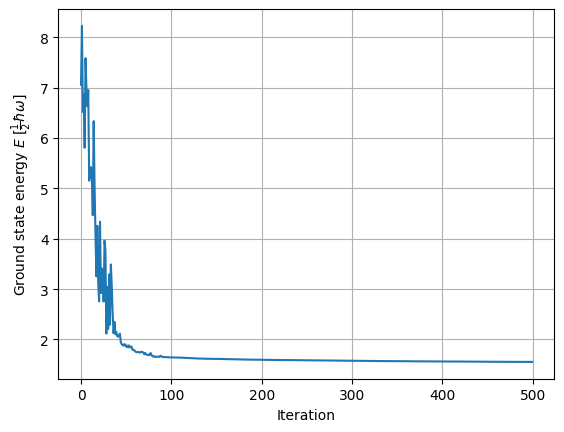

In [14]:
print(f"VQE Energy: {test_result[-1][0]}")

vqe_test_results = {k: np.real(test_result[k][0]) for k in range(len(test_result))}

plt.plot(vqe_test_results.keys(), vqe_test_results.values(), "-")
plt.ylabel(r"Ground state energy $E$ [$\frac{1}{2} \hbar \omega$]")
plt.xlabel("Iteration")
plt.tick_params(axis="both")
plt.grid()
plt.show()

Let's attempt to reproduce Fig. 1 from [[2](#Anderson2022)]. We will model $\mathrm{I_2}$ molecules as one-dimensional QDOs and calculate how the London dispersion energy $\Delta E$ changes according to the distance between the two parallel oscillators. We define the parameters such that the axial polarizability is $\alpha = 14.5 \ \mathrm{\AA^3}$ and the frequency is $\hbar \omega / 2 = 9.61 \ \mathrm{eV}$.

In [15]:
num_qdos = 2
num_qubits_per_qdo = 2
polarizability = 14.5  # Å^3
hbar_omega_half = 9.61  # eV

sample_distances = np.linspace(3.3, 5.5, 5)
print(sample_distances)

[3.3  3.85 4.4  4.95 5.5 ]


In [16]:
durations = []
VQE_energy = []

for interoscillator_distance in sample_distances:
    time1 = time.time()

    # Construct a model
    distances = np.zeros((num_qdos, num_qdos))
    for i in range(num_qdos):
        for j in range(num_qdos):
            distances[i][j] = abs(i - j) * interoscillator_distance

    vqe_hamiltonian = get_hamiltonian(
        num_qdos=num_qdos,
        num_qubits_per_qdo=num_qubits_per_qdo,
        coupling_constants=calculate_coupling_constants(
            polarizability=polarizability,
            distances=distances,
        ),
    )

    with ExecutionSession(qprog) as es:
        result = es.minimize(
            cost_function=vqe_hamiltonian,
            initial_params={"params": [1.0] * num_params},
            max_iteration=500,
        )

    VQE_energy.append(result[-1][0])

    time2 = time.time()
    duration = time2 - time1
    durations.append(duration)
    print(f"Distance: {interoscillator_distance:.4f}, Duration: {duration:.4f} seconds")

Distance: 3.3000, Duration: 9.9883 seconds
Distance: 3.8500, Duration: 9.3966 seconds
Distance: 4.4000, Duration: 9.7202 seconds
Distance: 4.9500, Duration: 13.0006 seconds
Distance: 5.5000, Duration: 9.9909 seconds


The theoretical value of the London dispersion force in this case can be calculated as follows. The Hamiltonian is:
$$
\def\Cvv{C_{\parallel,\parallel}}
\def\Cvh{C_{\parallel, \perp}}
\def\Chh{C_{\perp, \perp}}

\begin{equation*}
    \H = \frac{\hat{p}_1^2}{2\mu} + \frac{\hat{p}_2^2}{2\mu} + \frac{1}{2}\mu\omega^2(\hat{x}_1^2+\hat{x}_2^2 + \gamma \hat{x}_1 \hat{x}_2),
\end{equation*}
$$
where $\mu$ is the effective mass and $\gamma = -4\alpha R^{-3}$. By defining the transformed variables
$$
\hat{p}_\pm = \frac{1}{\sqrt{2}}(\hat{p}_1 \pm \hat{p}_2), \qquad \hat{x}_\pm = \frac{1}{\sqrt{2}}(\hat{x}_1 \pm \hat{x}_2),$$
the Hamiltonian can be rewritten in this new uncoupled basis as
$$
\H = \left(\frac{\hat{p}_+^2}{2\mu} + \frac{1}{2}\mu\omega^2\left(1+\frac{\gamma}{2}\right)\hat{x}_+^2\right) +\left(\frac{\hat{p}_-^2}{2\mu} + \frac{1}{2}\mu\omega^2\left(1-\frac{\gamma}{2}\right)\hat{x}_-^2\right).
$$
Therefore, the ground state energy is given by
$$
E = \frac{1}{2}\hbar \omega \left(\sqrt{1+\frac{\gamma}{2}} + \sqrt{1-\frac{\gamma}{2}}\right).
$$
In the absence of the London dispersion force—specifically, when the distance between the oscillators is $R = \infty$—we have $\gamma = 0$, which yields $E = \hbar \omega$. From this, the London dispersion energy can be calculated as:
$$
\Delta E = \frac{1}{2}\hbar \omega \left(\sqrt{1+\frac{\gamma}{2}} + \sqrt{1-\frac{\gamma}{2}} - 2\right).
$$
Below, we will confirm that VQE can obtain energy values close to this exact solution regardless of the distance between oscillators.

In [17]:
interoscillator_distances = np.arange(3.1, 6.1, 0.2)
gamma = -4 * polarizability / interoscillator_distances**3
exact_energies = np.sqrt(1 + gamma / 2) + np.sqrt(1 - gamma / 2)

Now, let's compare the London dispersion energy with the results obtained from the VQE.

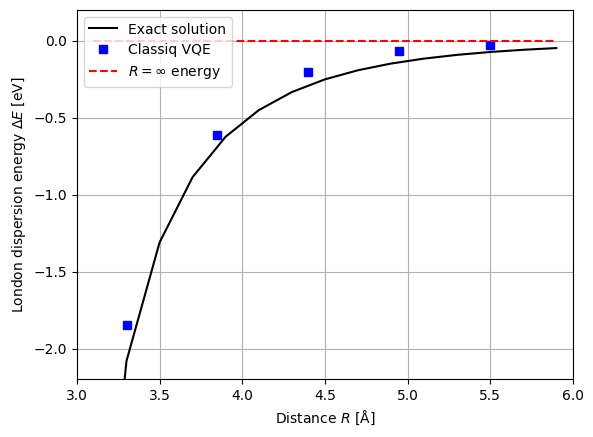

In [18]:
# R = ∞
r_inf_energy = 2.0

plt.plot(
    interoscillator_distances,
    (exact_energies - r_inf_energy) * hbar_omega_half,
    "k-",
    label="Exact solution",
)
plt.plot(
    sample_distances,
    (np.array(VQE_energy) - r_inf_energy) * hbar_omega_half,
    "bs",
    label="Classiq VQE",
)
plt.hlines(
    0,
    xmin=interoscillator_distances[0],
    xmax=interoscillator_distances[-1],
    colors="r",
    linestyles="--",
    label=r"$R = \infty$ energy",
)

plt.xlabel("Distance $R$ [Å]")
plt.ylabel(r"London dispersion energy $\Delta E$ [eV]")
plt.legend()
plt.ylim(-2.2, 0.2)
plt.xlim(3.0, 6.0)
plt.grid()

plt.show()

Next, let's investigate how $\Delta E$ changes with respect to the number of qubits $m$ (and the corresponding dimension $d$) assigned to each QDO.

In [19]:
def get_energies(
    interoscillator_distances: list[float], num_qubits_per_qdo: int, num_qdos: int = 2
) -> list[float]:
    energies = []
    for interoscillator_distance in interoscillator_distances:
        distances = np.zeros((num_qdos, num_qdos))
        for i in range(num_qdos):
            for j in range(num_qdos):
                distances[i][j] = abs(i - j) * interoscillator_distance

        vqe_hamiltonian = get_hamiltonian(
            num_qdos=num_qdos,
            num_qubits_per_qdo=num_qubits_per_qdo,
            coupling_constants=calculate_coupling_constants(
                polarizability=polarizability,
                distances=distances,
            ),
        )

        ham_matrix = hamiltonian_to_matrix(vqe_hamiltonian)
        energies.append(np.linalg.eigvalsh(ham_matrix).min())
    return np.array(energies)


energies_d_2 = get_energies(interoscillator_distances, num_qubits_per_qdo=1)
energies_d_4 = get_energies(interoscillator_distances, num_qubits_per_qdo=2)
energies_d_8 = get_energies(interoscillator_distances, num_qubits_per_qdo=3)
energies_d_16 = get_energies(interoscillator_distances, num_qubits_per_qdo=4)

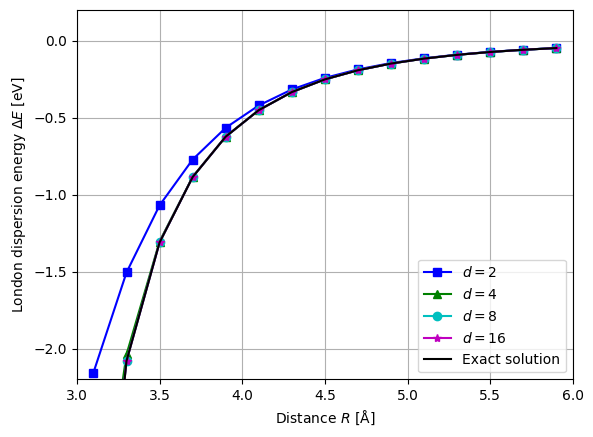

In [20]:
plt.plot(
    interoscillator_distances,
    (energies_d_2 - r_inf_energy) * hbar_omega_half,
    "bs-",
    label="$d = 2$",
)
plt.plot(
    interoscillator_distances,
    (energies_d_4 - r_inf_energy) * hbar_omega_half,
    "g^-",
    label="$d = 4$",
)
plt.plot(
    interoscillator_distances,
    (energies_d_8 - r_inf_energy) * hbar_omega_half,
    "co-",
    label="$d = 8$",
)
plt.plot(
    interoscillator_distances,
    (energies_d_16 - r_inf_energy) * hbar_omega_half,
    "m*-",
    label="$d = 16$",
)
plt.plot(
    interoscillator_distances,
    (exact_energies - r_inf_energy) * hbar_omega_half,
    "k-",
    label="Exact solution",
)

plt.xlabel("Distance $R$ [Å]")
plt.ylabel(r"London dispersion energy $\Delta E$ [eV]")
plt.legend()
plt.ylim(-2.2, 0.2)
plt.xlim(3.0, 6.0)
plt.grid()

plt.show()

Looking at this graph, we can see that the accuracy of the calculated energy increases as more qubits are used for each QDO.
The impact of $m$ (or $d$) on accuracy becomes more apparent as we vary the coupling constant $\gamma$.

In [21]:
gamma_list = -np.linspace(0.01, 2.0, 15)
interoscillator_distances_2 = (-4 * polarizability / gamma_list) ** (1 / 3)
exact_gs_energies = np.sqrt(1 + gamma_list / 2) + np.sqrt(1 - gamma_list / 2)


energies_d_2 = get_energies(interoscillator_distances_2, num_qubits_per_qdo=1)
energies_d_4 = get_energies(interoscillator_distances_2, num_qubits_per_qdo=2)
energies_d_8 = get_energies(interoscillator_distances_2, num_qubits_per_qdo=3)
energies_d_16 = get_energies(interoscillator_distances_2, num_qubits_per_qdo=4)

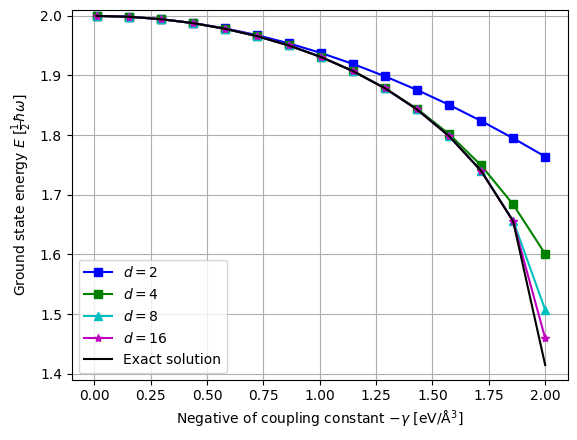

In [22]:
plt.plot(-gamma_list, energies_d_2, "bs-", label="$d = 2$")
plt.plot(-gamma_list, energies_d_4, "gs-", label="$d = 4$")
plt.plot(-gamma_list, energies_d_8, "c^-", label="$d = 8$")
plt.plot(-gamma_list, energies_d_16, "m*-", label="$d = 16$")
plt.plot(-gamma_list, exact_gs_energies, "k-", label="Exact solution")

plt.xlabel(r"Negative of coupling constant $-\gamma$ [eV/Å$^3$]")
plt.ylabel(r"Ground state energy $E$ [$\frac{1}{2} \hbar \omega$]")
plt.legend()
plt.ylim(1.39, 2.01)
plt.xlim(-0.1, 2.1)
plt.grid()

plt.show()

This graph makes it clearer that higher values of $d$ lead to greater accuracy. We can see that $d = 4$ is a good approximation to the exact solution until very large couplings $\gamma$. For reference, $-\gamma = 2$ corresponds to a Hamiltonian that is no longer positive-semidefinite, at this point the charged Drude particles dissociate from the nuclei and the system breaks down. For physically relevant systems, we expect to require value of $-\gamma$ much lower than 2, and we can therefore limit ourselves to small $d$ [[2](#Anderson2022)].

## Calculating many-body dispersion effect

Now that we know the exact London dispersion energy of two identical parallel QDOs along the inter-oscillator axis is
$$
\Delta E = \frac{1}{2}\hbar \omega \left(\sqrt{1+\frac{\gamma}{2}} + \sqrt{1-\frac{\gamma}{2}} - 2\right),
$$
where $\gamma = -4\alpha R^{-3}$, we might expect that adding a third QDO would result in a simple summation of these pairwise interactions.

Under this assumption, the total dispersion energy for a linear chain of three QDOs (with a distance $R$ between neighbors) would be given by:
$$
\Delta E = \hbar \omega \left(\sqrt{1+\frac{\gamma_1}{2}} + \sqrt{1-\frac{\gamma_1}{2}} - 2\right) + \frac{1}{2}\hbar \omega \left(\sqrt{1+\frac{\gamma_2}{2}} + \sqrt{1-\frac{\gamma_2}{2}} - 2\right),
$$
where $\gamma_1 = -4\alpha R^{-3},\ \gamma_2 = -4\alpha (2R)^{-3}$. Let's compare this to the results obtained by diagonalizing the Hamiltonian for $d=4$.

In [23]:
gamma_1_list = -4 * polarizability / interoscillator_distances**3
gamma_2_list = -4 * polarizability / (2 * interoscillator_distances) ** 3
deltae_two_body = 2 * (
    np.sqrt(1 + gamma_1_list / 2) + np.sqrt(1 - gamma_1_list / 2) - 2.0
) + (np.sqrt(1 + gamma_2_list / 2) + np.sqrt(1 - gamma_2_list / 2) - 2.0)
deltae_three_body = (
    get_energies(interoscillator_distances, num_qubits_per_qdo=2, num_qdos=3) - 3.0
)

Let's also try computing the energy by VQE using the following ansatz.

In [24]:
num_params = 4 * 10  # 10 layers, each with 4 parameters


@qfunc
def main(params: CArray[CReal, num_params], state: Output[QArray]):
    allocate(6, state)
    param_idx = 0
    for q1, q2 in [
        [0, 1],
        [2, 3],
        [4, 5],
        [1, 2],
        [3, 4],
        [0, 1],
        [2, 3],
        [4, 5],
        [1, 2],
        [3, 4],
    ]:
        ansatz_layer(params[param_idx : param_idx + 4], [state[q1], state[q2]])
        param_idx += 4


# Synthesize
qprog2 = synthesize(main)
qprog2 = set_quantum_program_execution_preferences(
    qprog2,
    preferences=ExecutionPreferences(
        num_shots=1,
        backend_preferences=ClassiqBackendPreferences(
            backend_name="simulator_statevector"
        ),
    ),
)
show(qprog2)

Quantum program link: https://platform.classiq.io/circuit/3AelZ149PJOjgpwrFi3HO2IV38D


In [25]:
num_qdos = 3
num_qubits_per_qdo = 2

sample_distances = np.linspace(3.1, 5.5, 5)
print(sample_distances)

[3.1 3.7 4.3 4.9 5.5]


In [26]:
durations2 = []
VQE_energy2 = []

for interoscillator_distance in sample_distances:
    time1 = time.time()

    # Construct a model
    distances = np.zeros((num_qdos, num_qdos))
    for i in range(num_qdos):
        for j in range(num_qdos):
            distances[i][j] = abs(i - j) * interoscillator_distance

    vqe_hamiltonian = get_hamiltonian(
        num_qdos=num_qdos,
        num_qubits_per_qdo=num_qubits_per_qdo,
        coupling_constants=calculate_coupling_constants(
            polarizability=polarizability,
            distances=distances,
        ),
    )

    with ExecutionSession(qprog2) as es:
        result = es.minimize(
            cost_function=vqe_hamiltonian,
            initial_params={"params": [1.0] * num_params},
            max_iteration=500,
        )

    VQE_energy2.append(result[-1][0])

    time2 = time.time()
    duration = time2 - time1
    durations2.append(duration)
    print(f"Distance: {interoscillator_distance:.4f}, Duration: {duration:.4f} seconds")

Distance: 3.1000, Duration: 17.1934 seconds
Distance: 3.7000, Duration: 24.3041 seconds
Distance: 4.3000, Duration: 23.4690 seconds
Distance: 4.9000, Duration: 17.1903 seconds
Distance: 5.5000, Duration: 17.5069 seconds


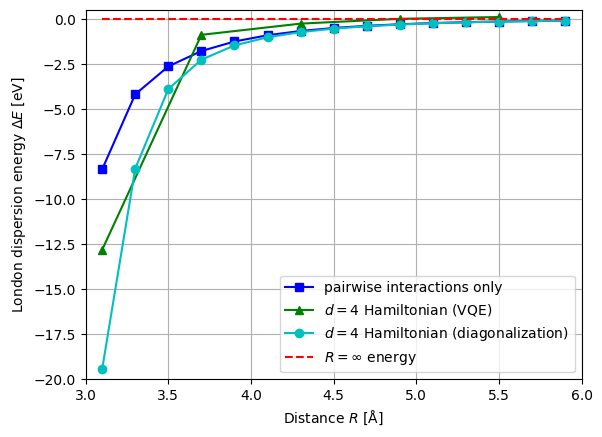

In [27]:
plt.plot(
    interoscillator_distances,
    deltae_two_body * hbar_omega_half,
    "bs-",
    label="pairwise interactions only",
)
plt.plot(
    sample_distances,
    (np.array(VQE_energy2) - 3.0) * hbar_omega_half,
    "g^-",
    label="$d = 4$ Hamiltonian (VQE)",
)
plt.plot(
    interoscillator_distances,
    deltae_three_body * hbar_omega_half,
    "co-",
    label="$d = 4$ Hamiltonian (diagonalization)",
)
plt.hlines(
    0,
    xmin=interoscillator_distances[0],
    xmax=interoscillator_distances[-1],
    colors="r",
    linestyles="--",
    label=r"$R = \infty$ energy",
)

plt.xlabel("Distance $R$ [Å]")
plt.ylabel(r"London dispersion energy $\Delta E$ [eV]")
plt.legend()
plt.ylim(-20.0, 0.5)
plt.xlim(3.0, 6.0)
plt.grid()

plt.show()

From this plot, we can see that diagonalizing the Hamiltonian for $d=4$ yields a larger energy shift at short distances between QDOs than when considering only two-body pairwise interactions. This suggests that many-body effects are playing a role.

## References

<a id='Jones2013'>[1]</a>: [A. P. Jones, J. Crain, V. P. Sokhan, T. W. Whitfield, and G. J. Martyna, Quantum Drude Oscillator Model of Atoms and Molecules: Many-Body Polarization and Dispersion Interactions for Atomistic Simulation, Phys. Rev. B 87, 144103 (2013).](https://doi.org/10.1103/PhysRevB.87.144103)

<a id='Anderson2022'>[2]</a>: [L. W. Anderson, M. Kiffner, P. K. Barkoutsos, I. Tavernelli, J. Crain, and D. Jaksch, Coarse-Grained Intermolecular Interactions on Quantum Processors, Phys. Rev. A 105, 062409 (2022).](https://doi.org/10.1103/PhysRevA.105.062409)